In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import numpy as np
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
import MGLensing
os.chdir(parent_dir)

my_colors = ['#035177', '#8ECAE6', '#FFDD03', '#ED91DC', '#F58300', '#78206E']
my_colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']


PyHMCode not installed!
PyHMCode not installed!
PyHMCode not installed!
euclidlib not installed! Euclid TR1 setup will not be available!
/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [2]:
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=1)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

In [3]:
# switch to the main directory
# change this to your path of the MGlensing repository
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

In [4]:
kmax07 = [482, 616, 716, 780, 818]
kmax04 = [273, 352, 409, 445, 467]
kmax03 = [206, 264, 306, 334, 350]
kmax01 = [68, 88, 102, 111, 116]

MGL = MGLensing.MGL("ini_files/config_files/config_minimise.yaml")
# MGL Cells 
ell_g = MGL.Survey.l_gc
zz_integr = MGL.Survey.zz_integr
nbin = MGL.Survey.nbin_l


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonli

In [5]:
# b_i = 0 (i > 1)
params = {'Omega_m' : 0.31,
    'Omega_c'   : 0.31-0.05,
    'Omega_cb'  : 0.31,
    'sigma8_cb' : 0.83,
    'As'      : np.exp(3.07)*1.e-10,
    'Omega_b'   : 0.05,
    'ns'        : 0.96,
    'h'         : 0.68,
    'Mnu'       : 0.0,
    'w0'        : -1.0,
    'wa'        : 0.0, 
    'b1_1': 1.187684,
    'b1_2': 1.312375,
    'b1_3': 1.45121,
    'b1_4': 1.60626,
    'b1_5': 1.779385,
    'b1L_1': 0.187684,
    'b1L_2': 0.312375,
    'b1L_3': 0.45121,
    'b1L_4': 0.60626,
    'b1L_5': 0.779385,
    'a1_IA'   : 0.67,
    'eta1_IA' : 1.66,
    'beta_IA' : 0.,
    'log10Mc_bc': 13.8,
    'eta_bc': -0.3,
    'beta_bc': -0.22 ,
    'log10Mz0_bc': 10.5,
    'thetaout_bc': 0.25,
    'thetainn_bc': -0.86,
    'log10Minn_bc': 12.4,
}  

In [6]:
# model for "reference" line: b1^2Pnl with baryons
model = {
    'nl_model' : 1,
    'bias_model' : 0,
    'baryon_model' : 3,
    'ia_model' : 0,
    'photoz_err_model' : 0
}
cl_ll_bar, cl_gg_bar, cl_lg_bar, cl_gl_bar = MGL.get_c_ells(params, model)
err_cl_ll, err_cl_gg, err_cl_lg  = MGL.get_errorbars(params)

params['log10Mc_bc'] = 10.2 
_, cl_gg_bar_weak, _, _ = MGL.get_c_ells(params, model)

params['log10Mc_bc'] = 14.8
_, cl_gg_bar_strong, _, _ = MGL.get_c_ells(params, model)

params['log10Mc_bc'] = 13.8

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

In [27]:
model = {
    'nl_model' : 1,
    'bias_model' : 2, #heft 
    'baryon_model' : 3,
    'ia_model' : 0,
    'photoz_err_model' : 0
}
params['b2L_1'] = -0.18
params['b2L_2'] = -0.23 
params['b2L_3'] = -0.27
params['b2L_4'] = -0.37
params['b2L_5'] = -0.43


params['bs2L_1'] = 0.4 #0.3
params['bs2L_2'] = 0.5 
params['bs2L_3'] = 0.56
params['bs2L_4'] = 0.7
params['bs2L_5'] = 0.8

params['blaplL_1'] = -1.1 #-1.
params['blaplL_2'] = -1. 
params['blaplL_3'] = -0.8
params['blaplL_4'] = -0.9
params['blaplL_5'] = -0.8

cl_ll_heft, cl_gg_heft, cl_lg_heft, cl_gl_heft = MGL.get_c_ells(params, model)

params['b2L_1'] = -0.17
params['b2L_2'] = -0.23 #-0.24 
params['b2L_3'] = -0.26
params['b2L_4'] = -0.37
params['b2L_5'] = -0.43 #-0.44


params['bs2L_1'] = 0.4 
params['bs2L_2'] = 0.5 
params['bs2L_3'] = 0.56
params['bs2L_4'] = 0.7
params['bs2L_5'] = 0.8

params['blaplL_1'] = -1.2
params['blaplL_2'] = -1.1 
params['blaplL_3'] = -0.9
params['blaplL_4'] = -1.0
params['blaplL_5'] = -0.9

_, cl_gg_heft_weak, _, _ = MGL.get_c_ells(params, model)

params['b2L_1'] = -0.2
params['b2L_2'] = -0.23 
params['b2L_3'] = -0.26
params['b2L_4'] = -0.36
params['b2L_5'] = -0.42


params['bs2L_1'] = 0.3
params['bs2L_2'] = 0.5 
params['bs2L_3'] = 0.6
params['bs2L_4'] = 0.7
params['bs2L_5'] = 0.8

params['blaplL_1'] = -1.1 
params['blaplL_2'] = -1. 
params['blaplL_3'] = -0.75 #-0.7
params['blaplL_4'] = -0.84 #-0.8
params['blaplL_5'] = -0.8

_, cl_gg_heft_strong, _, _ = MGL.get_c_ells(params, model)

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

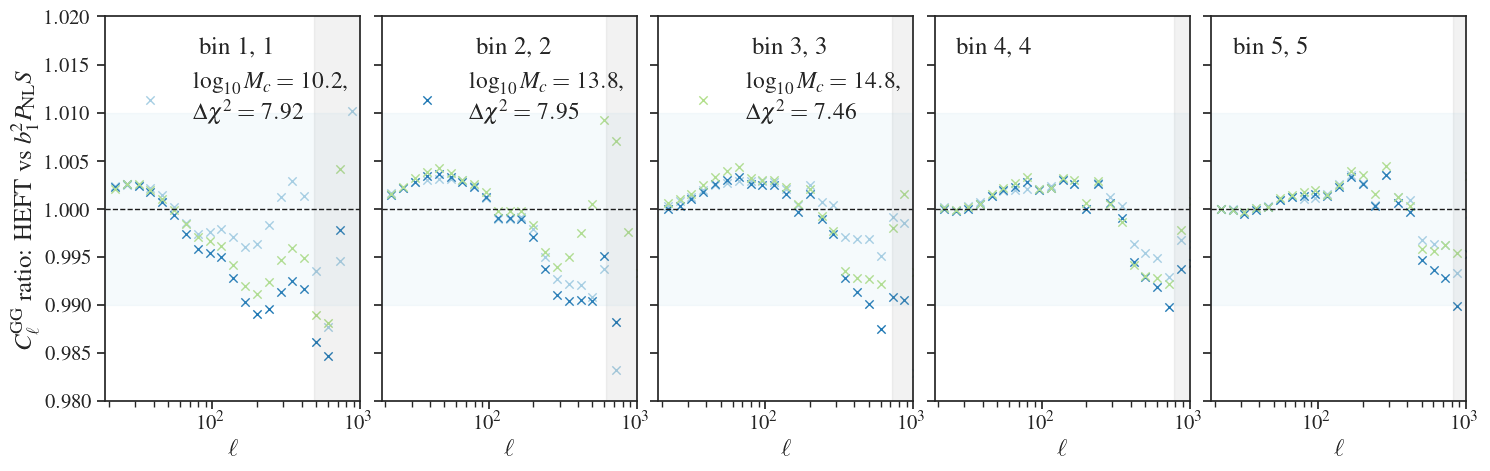

In [ ]:

ell_cuts = [kmax07]
ell =ell_g
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(1, nbin + 1, width_ratios=[1] * nbin + [0.05], wspace=0.1)
ax = [fig.add_subplot(gs[i]) for i in range(nbin)]
for i in range(nbin):
    ax[i].hlines(1., min(ell)-3, max(ell), 'k', linestyle='--')
    ax[i].scatter(ell, cl_gg_heft_weak[:,i,i]/cl_gg_bar_weak[:,i,i],  marker='x', label='$\log_{10}M_c=10.2$,\n $\Delta \chi^2=7.92$' if i==0 else '') 
    ax[i].scatter(ell, cl_gg_heft[:,i,i]/cl_gg_bar[:,i,i],  marker='x', label='$\log_{10}M_c=13.8$,\n $\Delta \chi^2=7.95$' if i==1 else '') 
    ax[i].scatter(ell, cl_gg_heft_strong[:,i,i]/cl_gg_bar_strong[:,i,i],  marker='x', label='$\log_{10}M_c=14.8$,\n $\Delta \chi^2=7.46$' if i==2 else '') 
    
    for cuts in ell_cuts:
        ax[i].axvspan(1000, cuts[i], color='gray', alpha=0.1)
        ax[i].axhspan(0.99, 1.01, color='C0', alpha=0.1)
    ax[i].set_xscale('log')
    ax[i].set_xlim(min(ell)-3, 1000)
    ax[i].set_ylim(0.98, 1.02)
    ax[i].tick_params(axis='both', which='major', labelsize=15) 
    if i > 0:
        ax[i].tick_params(labelleft=False)   
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].legend(loc='upper left', title_fontsize=18,fontsize=17, title='bin ' + str(i + 1) + ', ' + str(i + 1), frameon=False)
ax[0].set_ylabel(r'$C^{\rm GG}_\ell$ ratio: HEFT vs $b_1^2P_{\rm NL}S$', fontsize=18) 
#ax[0].legend(loc='upper left', fontsize=12)
plt.tight_layout()
#plt.savefig('quantify_rainbow.pdf', bbox_inches='tight', pad_inches=0.2, dpi=300)